In [3]:
import numpy as np

In [9]:
res=np.loadtxt('residuals',dtype=complex)

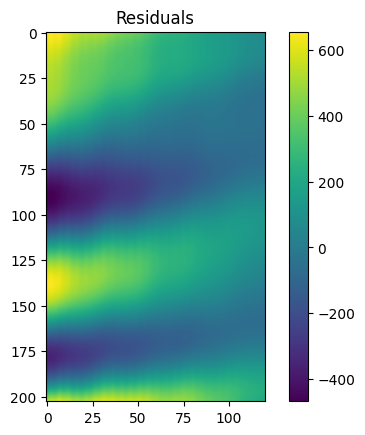

In [11]:
import matplotlib.pyplot as plt

plt.imshow(res.imag)
plt.title("Residuals")
plt.colorbar()

In [1]:
import numpy as np
from uvtools.dspec import gen_window
from uvtools.utils import FFT
# pr=cProfile.Profile()

def data_dly_fr(data, freqs, times, windows=None,
                    freq_window_kwargs=None, time_window_kwargs=None):
    """
    Transform data to delay fringe-rate space
    
    This function takes a 2D array of visibility data (in units of Jy), as well 
    as the corresponding frequency and time arrays (in units of Hz and JD, respectively), 
    and makes a 2x2 grid of plots where each plot shows each one of the possible choices 
    for Fourier transforming along an axis. The upper-left plot is in the frequency-time 
    domain; the upper-right plot is in the frequency-fringe-rate domain; the lower-left 
    plot is in the delay-time domain; and the lower-right plot is in the delay-fringe-rate 
    domain.
    
    Parameters
    ----------
    data : ndarray, shape=(NTIMES,NFREQS)
        Array containing the visibility to be plotted. Assumed to be in units of Jy. 
        
    freqs : ndarray, shape=(NFREQS,)
        Array containing the observed frequencies. Assumed to be in units of Hz.
        
    times : ndarray, shape=(NTIMES,)
        Array containing the observed times. Assumed to be in units of JD.
        
    windows : tuple of str or str, optional
        Choice of taper to use for the fringe-rate and delay transforms. Must be 
        either tuple, list, or string. If a tuple or list, then it must be either 
        length 1 or length 2; if it is length 2, then the zeroth entry is the taper 
        to be applied along the time axis for the fringe-rate transform, with the 
        other entry specifying the taper to be applied along the frequency axis 
        for the delay transform. Each entry is passed to uvtools.dspec.gen_window. 
        If ``windows`` is a length 1 tuple/list or a string, then it is assumed 
        that the same taper is to be used for both axes. Default is to use no 
        taper (or, equivalently, a boxcar).

    freq_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        frequency taper. Default is to pass no keyword arguments.
        
    time_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        time taper. Default is to pass no keyword arguments.
    
    Returns
    -------
    data_dl_fr :
        data in delay-fringe rate space
    """
    # do some data prep
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}
    if windows is not None:
        time_window = gen_window(windows, times.size, **time_window_kwargs)
        freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)
    else:
        time_window = gen_window(None, times.size, **time_window_kwargs)
        freq_window = gen_window(None, freqs.size, **freq_window_kwargs)
        
    time_window = time_window[:, None]
    freq_window = freq_window[None, :]
    # data_fr = FFT(data * time_window, axis=0)
    # data_dly = FFT(data * freq_window, axis=1)
    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)
    
    # fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3 # mHz
    # dlys = fourier_freqs(freqs) * 1e9 # ns

    return data_fr_dly


In [2]:
from pyuvdata import UVData

uvd=UVData()
uvd.read('/Users/user/Documents/Codes/hydra-pspec-systematic/hera_val/vis_corrupted_test.uvh5')
antpairpols = uvd.get_antpairpols()
vis=uvd.get_data(antpairpols[0])
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

uvd.read('vis-eor-fgs.uvh5')
antpairpols = uvd.get_antpairpols()
vis_og=uvd.get_data(antpairpols[0])
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.


In [3]:
dl_fr_residual=data_dly_fr(data=np.abs(vis)/np.abs(vis_og),freqs=freqs,times=lsts,windows='blackman-harris')
data_og=data_dly_fr(data=vis_og,freqs=freqs,times=lsts,windows='blackman-harris')

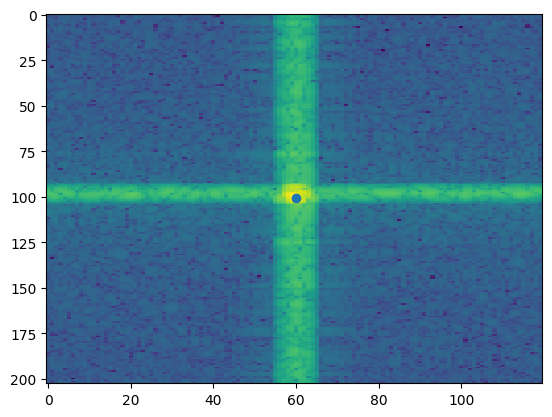

In [6]:
from uvtools.plot import waterfall
import matplotlib.pyplot as plt

waterfall(data_og.real,aspect='auto')
plt.scatter(60,101)

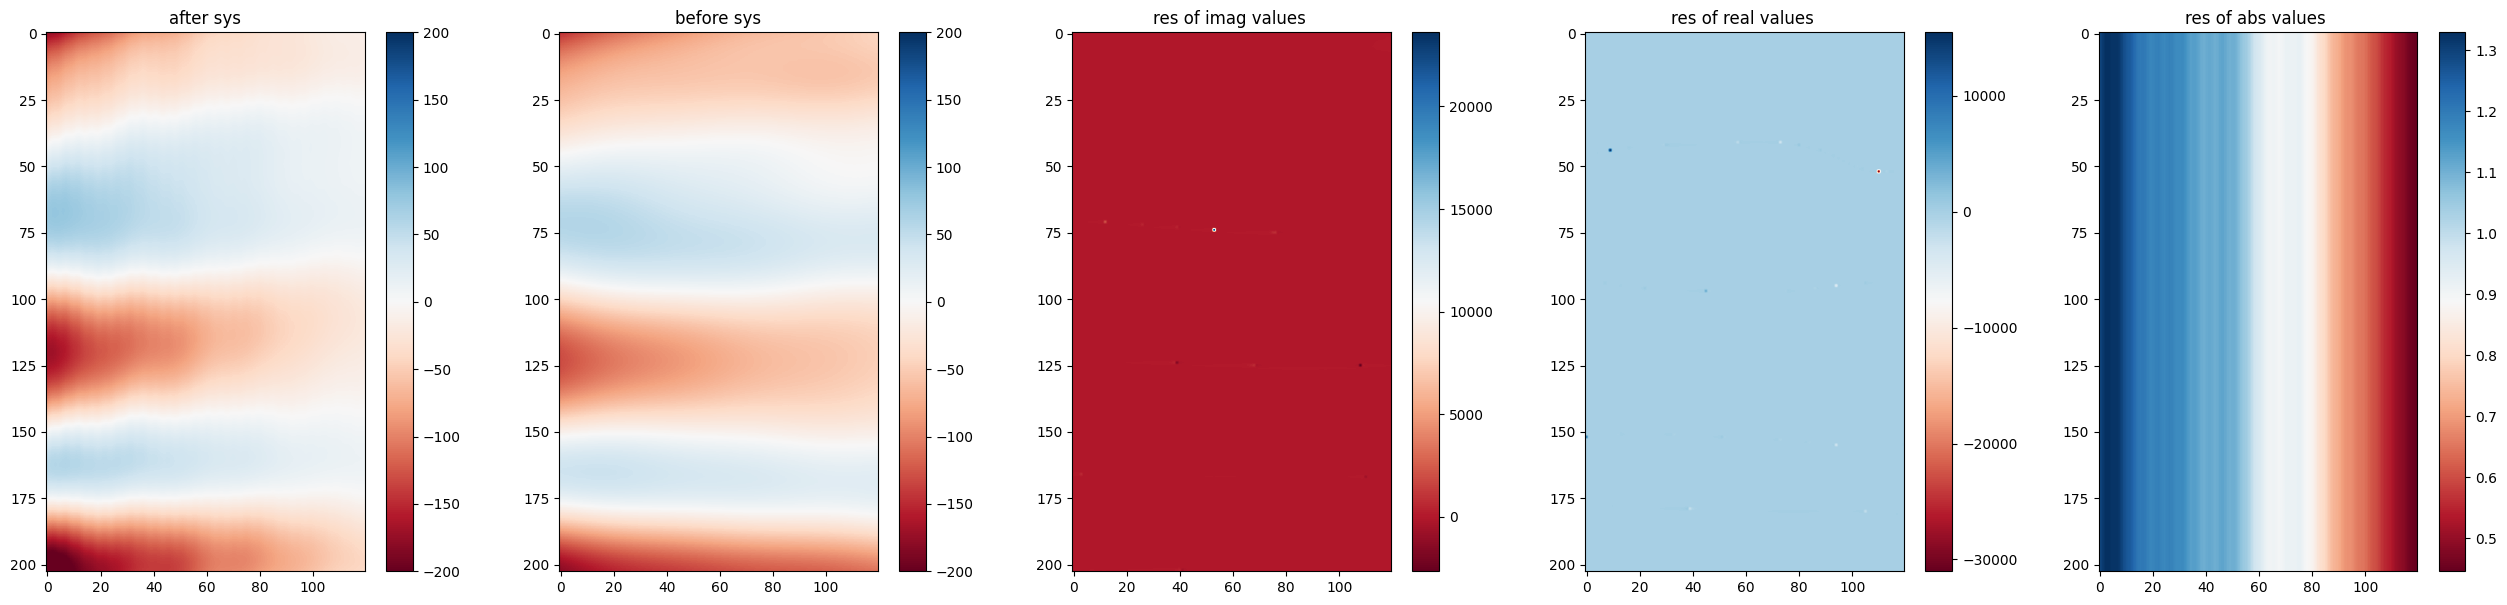

In [7]:
fig, ax = plt.subplots(1, 5, figsize=(32,7))
im0=ax[0].imshow(vis.real,vmin=-200,vmax=200,cmap='RdBu')
ax[0].set_title("after sys")

im1=ax[1].imshow(vis_og.real,vmin=-200,vmax=200,cmap='RdBu')
ax[1].set_title("before sys")

im2=ax[2].imshow(np.imag(vis)/np.imag(vis_og),cmap='RdBu')
ax[2].set_title("res of imag values ")

im3=ax[3].imshow(np.real(vis)/np.real(vis_og),cmap='RdBu')
ax[3].set_title("res of real values ")

im4=ax[4].imshow(np.abs(vis)/np.abs(vis_og),cmap='RdBu')
ax[4].set_title("res of abs values ")

plt.colorbar(im0)
plt.colorbar(im1)
plt.colorbar(im2)
plt.colorbar(im3)
plt.colorbar(im4)

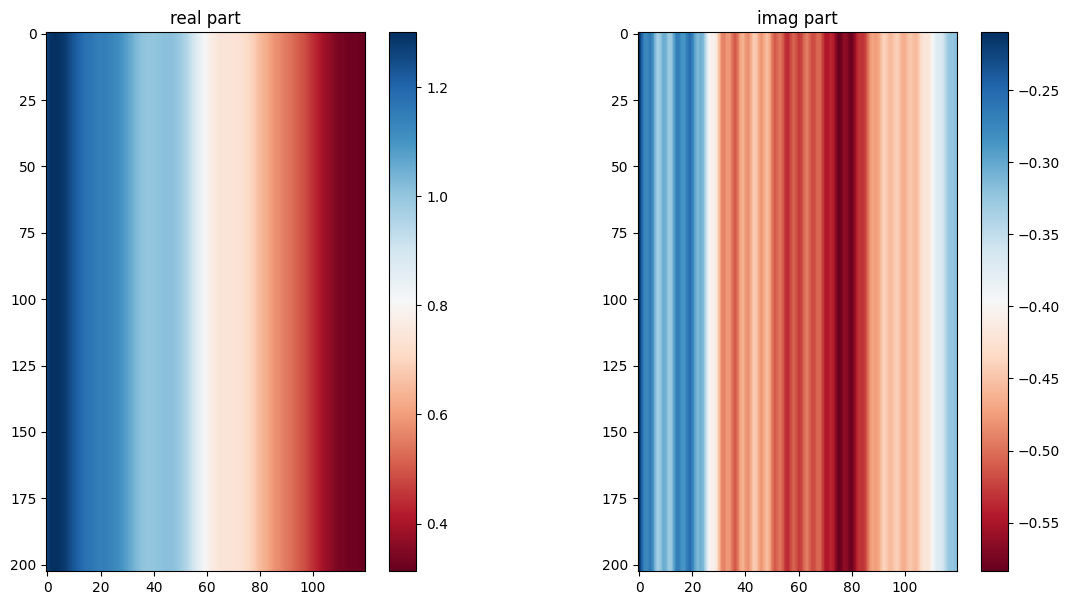

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))
data_frac = vis/vis_og
im0=ax[0].imshow(data_frac.real,cmap='RdBu')
ax[0].set_title("real part")
im1=ax[1].imshow(data_frac.imag,cmap='RdBu')
ax[1].set_title("imag part")
plt.colorbar(im0)
plt.colorbar(im1)

Casting complex values to real discards the imaginary part


Text(0.5, 1.0, 'Comparing fits')

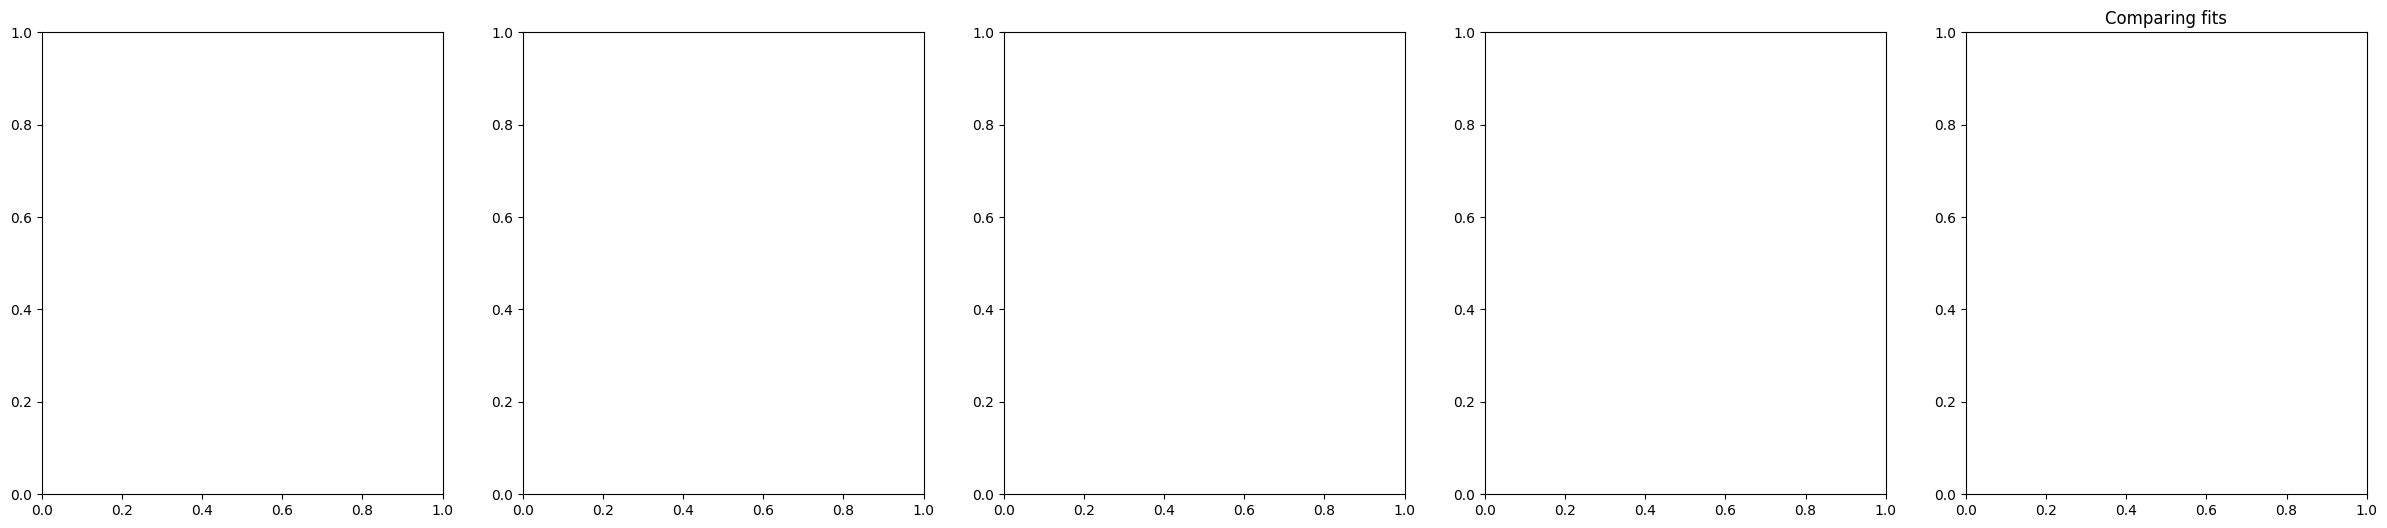

In [278]:
# Load data
nm_y=np.zeros(shape=120)
nm_x=np.arange(0,120,1,dtype=int)
nm_list=np.array([nm_x,nm_y],dtype=int).T

hj = ss.h_j_op(freqs=freqs, lsts=lsts, nm_list=nm_list)

hj = hj.reshape((120,-1,120))
new_d=np.empty([len(lsts),len(freqs)])
fig,ax=plt.subplots(1,5,figsize=(30,6))
for i in range(len(lsts)):
    # Just get one time
    hj_op = hj[:,120-i,:] # (Nfreqs, Nmodes)
    dd=data_frac[120-i,:]
    # # Fitting function for leastsq
    # def fit_fn(x):
    #     xre = x[:x.size//2]
    #     xim = x[x.size//2:]
    #     y = hj_op @ (xre + 1.j*xim)
    #     return np.concatenate(( (dd - y).real, (dd - y).imag ))
    # Define the fitting function
    def fit_fn(x, hj_op, dd, real_weight=1.0, imag_weight=1.0):
        xre = x[:x.size//2]
        xim = x[x.size//2:]
        y = hj_op @ (xre + 1.j * xim)
        # Compute residuals with weighted real and imaginary parts
        residuals_real = real_weight * (dd.real - y.real)
        residuals_imag = imag_weight * (dd.imag - y.imag)
        return np.concatenate((residuals_real, residuals_imag))
    # Run leastsq fit
    from scipy.optimize import leastsq
    x0 = np.zeros(2*120) # separate real and imag values, hence 2*120
    xx, _ = leastsq(fit_fn, x0)

    # Re-combine best fit real/imag parts into complex best fit coeffs
    xre = xx[:xx.size//2]
    xim = xx[xx.size//2:]
    ybf = hj_op @ (xre + 1.j*xim)
    new_d[i,:]=ybf
    # # Plot results
    # ax[i].plot(dd.real, 'k-',label='True real')
    # ax[i].plot(ybf.real, 'r--',label='Fit real')

    # ax[i].plot(dd.imag, 'k-',label='True imag')
    # ax[i].plot(ybf.imag, 'y--',label='Fit imag')

    # ax[i].legend()
plt.title("Comparing fits")

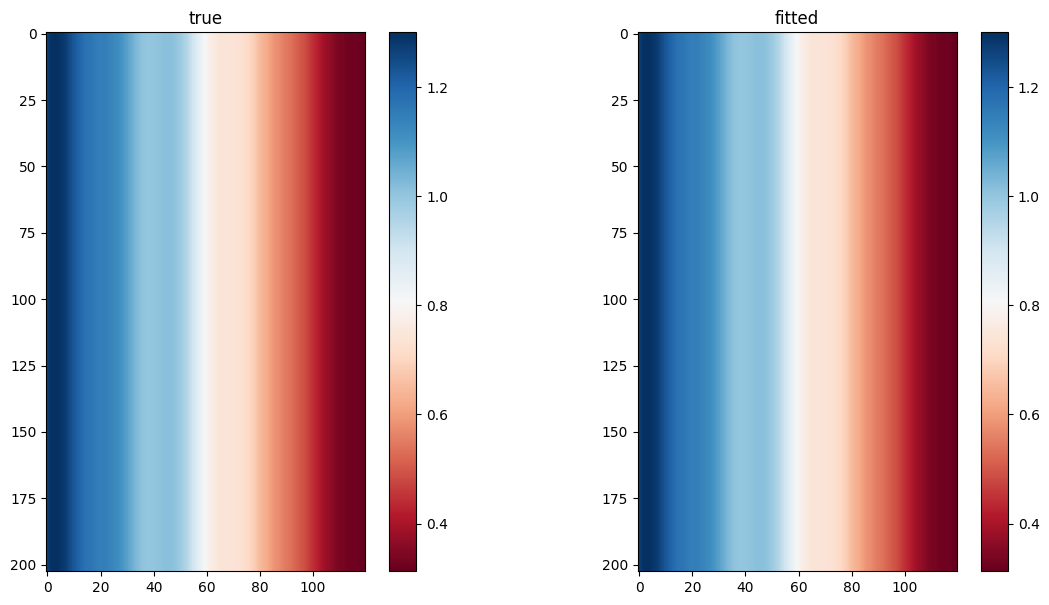

In [281]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))
im0=ax[0].imshow(data_frac.real,cmap='RdBu')
ax[0].set_title("true")
im1=ax[1].imshow(new_d.real,cmap='RdBu')
ax[1].set_title("fitted")
plt.colorbar(im0)
plt.colorbar(im1)

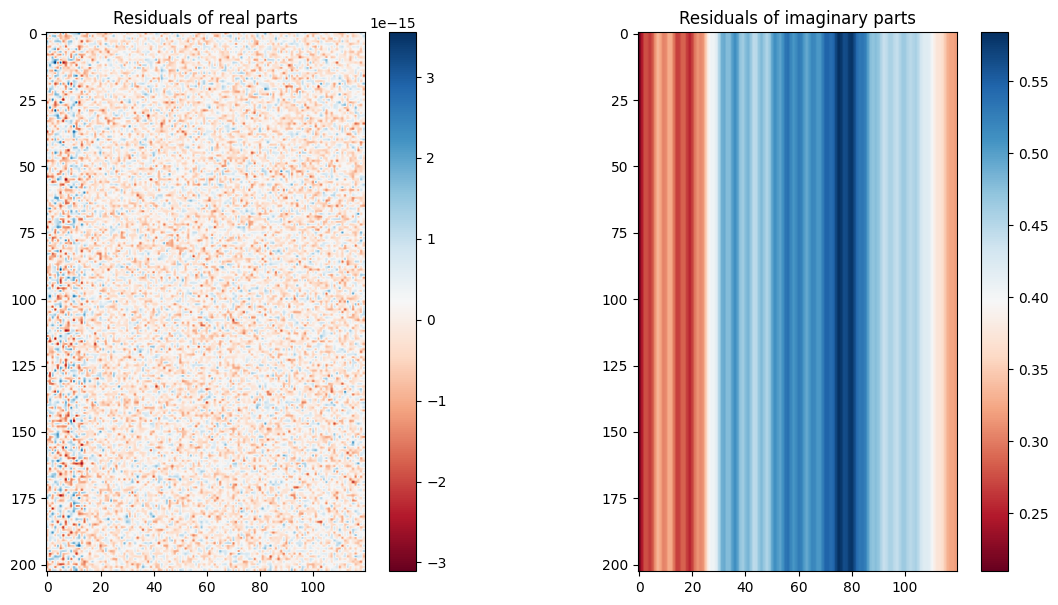

In [286]:
residuals=new_d-data_frac
fig, ax = plt.subplots(1, 2, figsize=(14,7))
im0=ax[0].imshow(residuals.real,cmap='RdBu')
ax[0].set_title("Residuals of real parts")
im1=ax[1].imshow(residuals.imag,cmap='RdBu')
ax[1].set_title("Residuals of imaginary parts")
plt.colorbar(im0)
plt.colorbar(im1)

In [264]:
fringe_rates = fourier_freqs(lsts)
dlys = fourier_freqs(freqs) * 1e9 # ns
FR, DL = np.meshgrid(fringe_rates, dlys, indexing='ij')

In [271]:
new_d=np.empty([203,len(ybf)])
for i in range(203):
    new_d[i,:]=ybf

Casting complex values to real discards the imaginary part


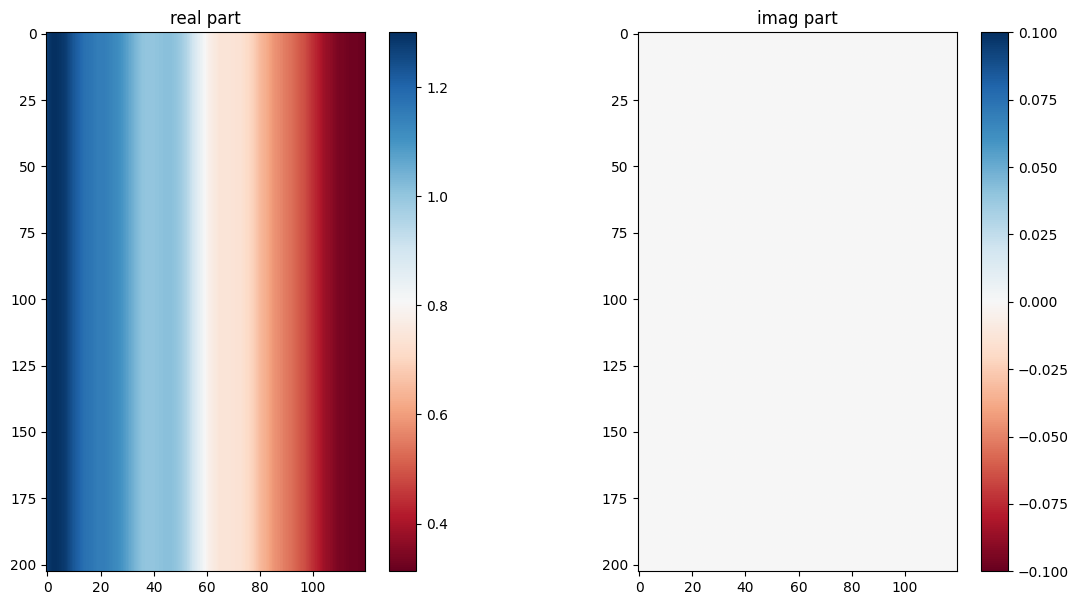

In [272]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))
im0=ax[0].imshow(new_d.real,cmap='RdBu')
ax[0].set_title("real part")
im1=ax[1].imshow(new_d.imag,cmap='RdBu')
ax[1].set_title("imag part")
plt.colorbar(im0)
plt.colorbar(im1)

Text(0.5, 0, 'delays')

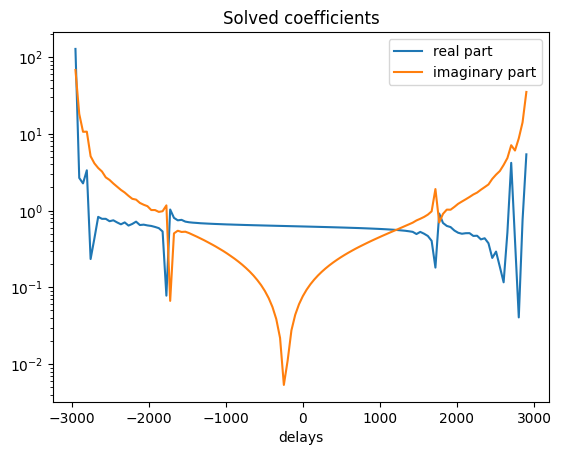

In [268]:
plt.yscale('log')
plt.plot(dlys,np.abs(xre),label='real part')
plt.plot(dlys,np.abs(xim),label="imaginary part")
plt.legend()
plt.title("Solved coefficients")
plt.xlabel('delays')

In [124]:
h_j_coeff=np.empty(shape=[len(h_j),120])
for i in range(120):
    h_j_coeff[:,i]=(coeffs_res[i]*h_j[:,i])

Casting complex values to real discards the imaginary part


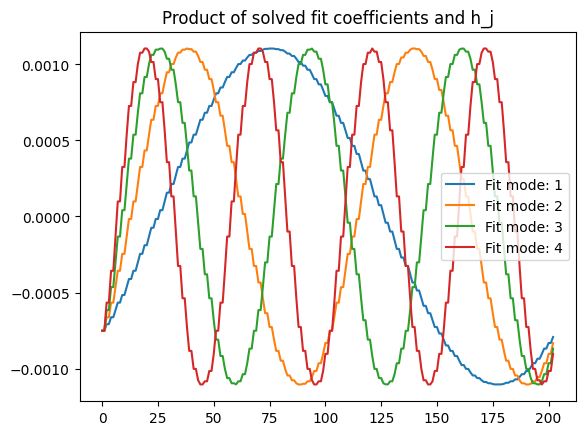

In [126]:
h_j_res=h_j_coeff.reshape([np.shape(data_frac)[0],np.shape(data_frac)[1],120])
# plt.ylim(-10e-7,10e-7)
for i in range(1,5):
    plt.plot(h_j_res[:,1,i].real,label='Fit mode: '+str(i))
plt.title("Product of solved fit coefficients and h_j")
plt.legend()

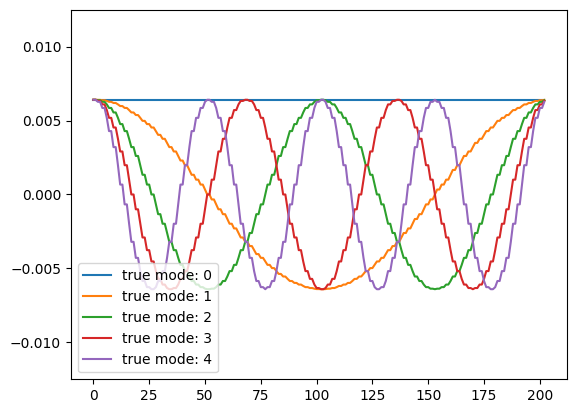

In [127]:
plt.ylim(-0.0125,0.0125)
for i in range(5):
    plt.plot((h_j_res[:,1,i]).real,label='true mode: '+str(i))
plt.legend()

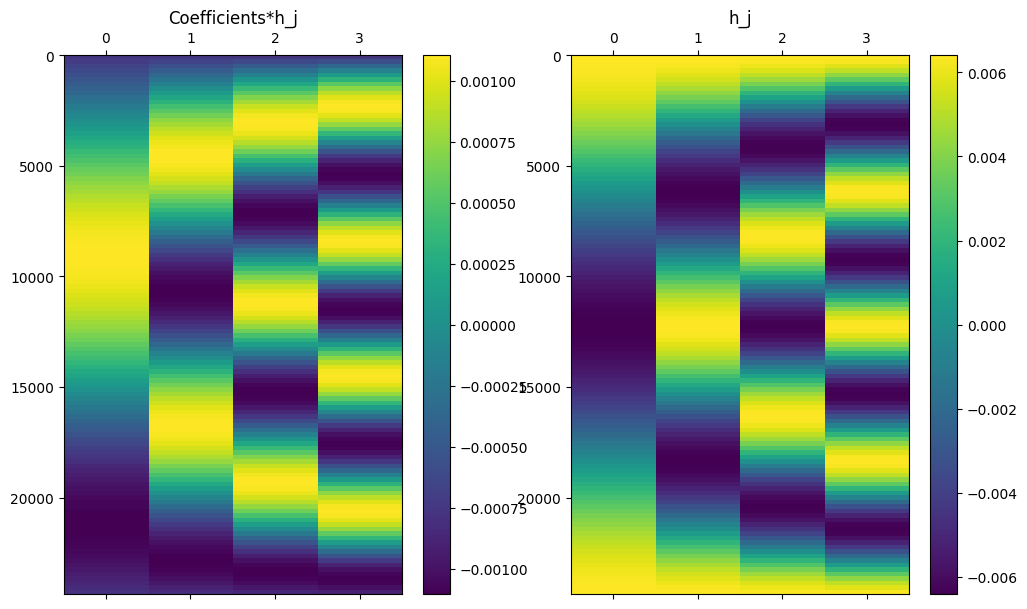

In [128]:
fig,ax=plt.subplots(1,2,figsize=(12,7))
mat1=ax[0].matshow(h_j_coeff[:,1:5].real,aspect='auto')
ax[0].set_title("Coefficients*h_j")
plt.colorbar(mat1)
mat2=ax[1].matshow(h_j[:,1:5].real,aspect='auto')
ax[1].set_title("h_j")
plt.colorbar(mat2)

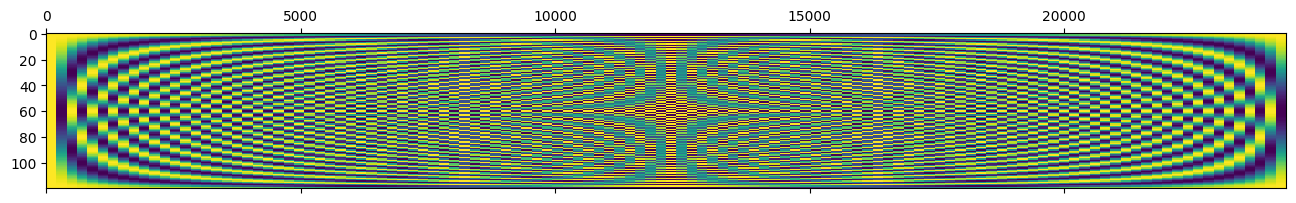

In [55]:
# for i in range(5):
#     h_j_plot=h_j[:,i].reshape(np.shape(data_frac))
plt.matshow(h_j.T.real,aspect='auto')

In [198]:
np.where((FR>-1) & (FR<1))

(array([101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
        101, 101, 101, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102,
        102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102,
        102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102,
        102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102,
        102, 102, 102, 102, 102, 102, 102, 102, 102

In [195]:
np.shape(np.where((FR>-1) & (FR<1))[:][1])

(240,)

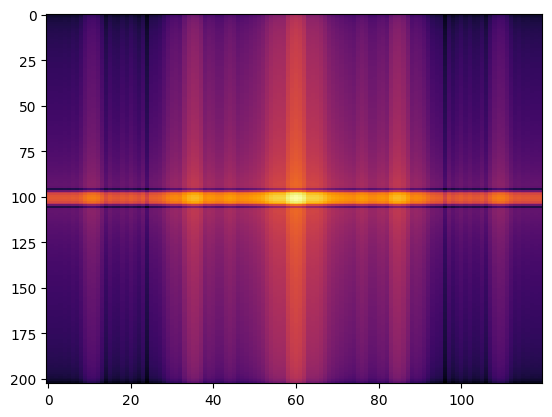

In [129]:
waterfall(dl_fr_residual,cmap='inferno')

In [125]:
dl_fr_data=data_dly_fr(data=vis_og,freqs=freqs,times=lsts,windows='blackman-harris')
dl_fr_sys=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')

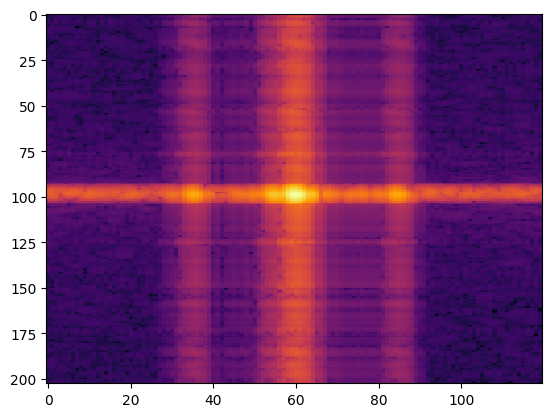

In [130]:
waterfall(dl_fr_sys,cmap='inferno')

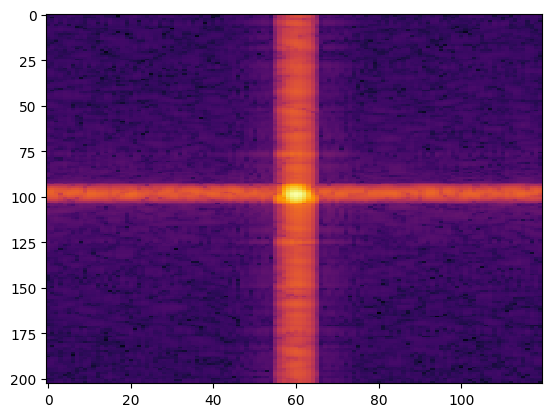

In [127]:
waterfall(dl_fr_data,cmap='inferno')

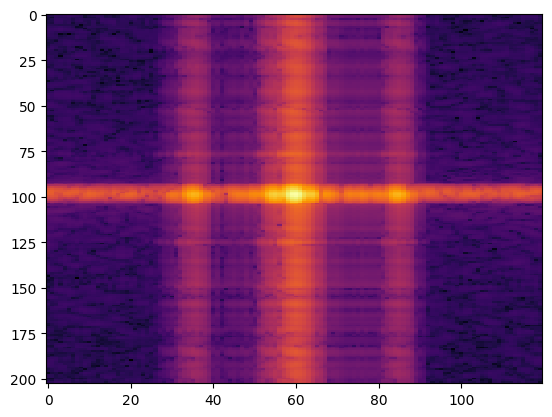

In [132]:
waterfall(dl_fr_sys-dl_fr_data,cmap='inferno')

Text(0.5, 1.0, 'After sys')

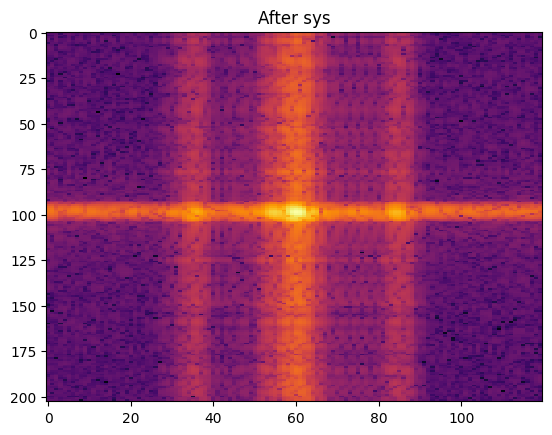

In [121]:
import matplotlib.pyplot as plt
from uvtools.plot import waterfall
waterfall(data.imag,mode='log',cmap='inferno')
plt.title("After sys")

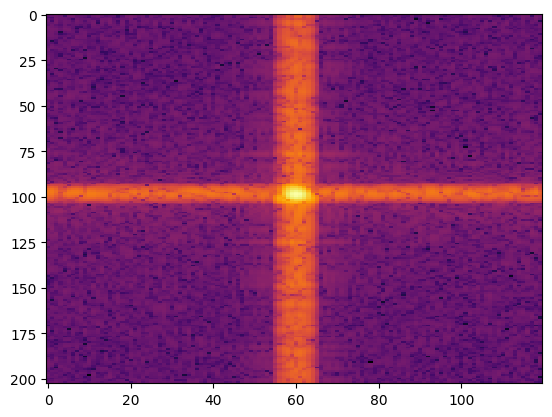

In [90]:
waterfall(data_og.imag,mode='log',cmap='inferno')

(array([ 1.,  0.,  2.,  2.,  2.,  5.,  7.,  8.,  9., 13., 12., 14., 16.,
        28., 11., 31., 30., 34., 38., 40., 47., 43., 51., 42., 47., 50.,
        38., 46., 36., 34., 45., 39., 34., 20., 24., 16., 11., 13.,  8.,
        16.,  9.,  6.,  5.,  4.,  4.,  1.,  0.,  5.,  1.,  2.]),
 array([187.46782628, 189.29610369, 191.1243811 , 192.9526585 ,
        194.78093591, 196.60921332, 198.43749073, 200.26576813,
        202.09404554, 203.92232295, 205.75060036, 207.57887777,
        209.40715517, 211.23543258, 213.06370999, 214.8919874 ,
        216.7202648 , 218.54854221, 220.37681962, 222.20509703,
        224.03337444, 225.86165184, 227.68992925, 229.51820666,
        231.34648407, 233.17476147, 235.00303888, 236.83131629,
        238.6595937 , 240.4878711 , 242.31614851, 244.14442592,
        245.97270333, 247.80098074, 249.62925814, 251.45753555,
        253.28581296, 255.11409037, 256.94236777, 258.77064518,
        260.59892259, 262.4272    , 264.2554774 , 266.08375481,
        267.

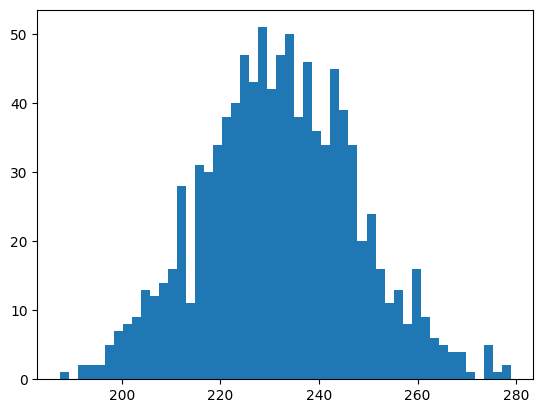

In [66]:
import numpy as np
from scipy.stats import invgamma
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)

beta=47175.800535647475
Alpha=202.0
# rv = invgamma(a=Alpha+1)
x_vals=np.loadtxt('x_resample')
ax.hist(x_vals, bins=50)

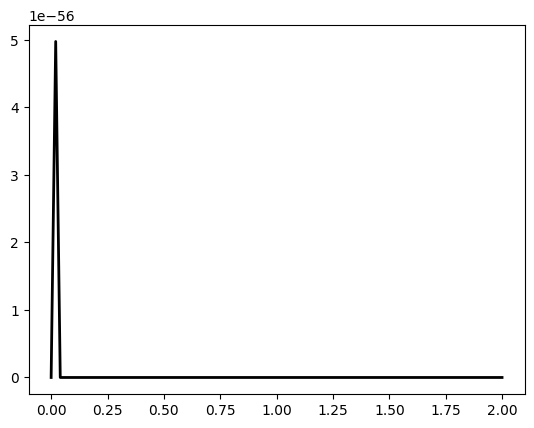

In [54]:
x=np.linspace(0,2,100)
rv=invgamma(Alpha+1)
fig, ax = plt.subplots(1, 1)
ax.plot(x, rv.pdf(x), 'k-', lw=2, label='frozen pdf')

(array([0.00067489, 0.00067489, 0.00314948, 0.00539911, 0.00899851,
        0.01349776, 0.01799702, 0.02159642, 0.01889687, 0.02744545,
        0.02272124, 0.0211465 , 0.01687221, 0.0132728 , 0.0096734 ,
        0.00697384, 0.00652392, 0.00404933, 0.00314948, 0.00134978,
        0.00089985]),
 array([188.35432213, 192.79950278, 197.24468343, 201.68986409,
        206.13504474, 210.58022539, 215.02540604, 219.47058669,
        223.91576734, 228.36094799, 232.80612864, 237.25130929,
        241.69648995, 246.1416706 , 250.58685125, 255.0320319 ,
        259.47721255, 263.9223932 , 268.36757385, 272.8127545 ,
        277.25793515, 281.70311581]),
 [<matplotlib.patches.Polygon at 0x326a58800>])

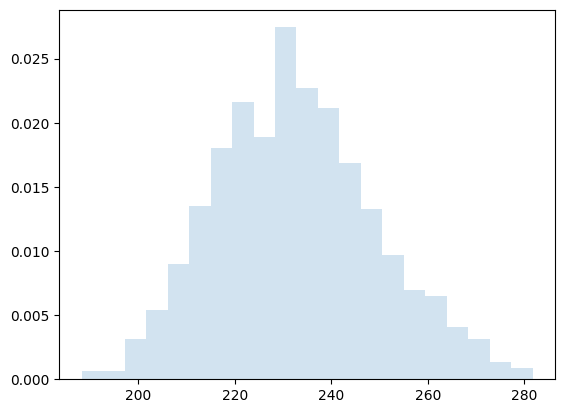

In [93]:
r = invgamma.rvs(Alpha+1, size=1000)*beta
fig, ax = plt.subplots(1, 1)
ax.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)

In [100]:
min(r), max(r)

(188.35432213255336, 281.70311580594586)

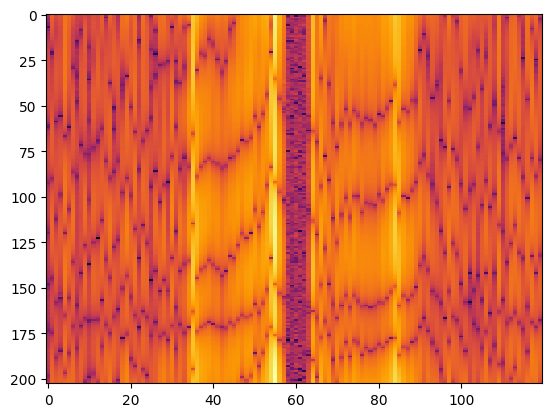

In [99]:
sk=np.loadtxt('sk_save',dtype=complex)
waterfall(sk.real,mode='log',cmap='inferno')

In [95]:
pwd

'/Users/user/Documents/Codes/hydra-pspec-systematic'